In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from config import config

In [85]:
train_df = pd.read_parquet(config.path.train[0])
feat = pd.read_parquet(config.path.features[0])

# train EDA

In [87]:
info = pd.DataFrame({
    'name_cols': train_df.columns,
    'isna': train_df.isna().sum(),
    'dtypes': train_df.dtypes,
    'unique': train_df.nunique(),
})
display(info)

,name_cols,isna,dtypes,unique
app_id,app_id,0,str,37817
request_received,request_received,0,datetime64[ns],37891
date_part,date_part,0,str,73
request_id,request_id,0,str,37891
req_loan_amount,req_loan_amount,0,float32,962
req_term,req_term,0,int64,7
verif_compl,verif_compl,0,str,2
offer_id,offer_id,0,int64,951
variant_no,variant_no,0,int64,50
offer_type,offer_type,0,str,2


In [39]:
cat_cols = train_df.select_dtypes(include=['string']).columns
for col in cat_cols:
    train_df[col] = train_df[col].astype('category')

In [78]:
info[info['dtypes'] == 'category']

,name_cols,isna,dtypes,unique
app_id,app_id,0,category,37817
date_part,date_part,0,category,73
request_id,request_id,0,category,37891
verif_compl,verif_compl,0,category,2
offer_type,offer_type,0,category,2
risk_level_map,risk_level_map,0,category,4
verif_need,verif_need,0,category,2
need_2ndfl,need_2ndfl,0,category,3
channel,channel,0,category,2
basket_name,basket_name,799914,category,12


In [41]:
le_df = train_df[['verif_compl', 'offer_type', 'risk_level_map', 'verif_need', 'need_2ndfl', 'channel']]

In [42]:
display(le_df['channel'].unique(), # n
        le_df['verif_compl'].unique(), # y
        le_df['offer_type'].unique(), # d
        le_df['risk_level_map'].unique(), # y
        le_df['verif_need'].unique(), # y
        le_df['need_2ndfl'].unique()) # y

['Internet', 'Front']
Categories (2, str): ['Front', 'Internet']

['N', 'Y']
Categories (2, str): ['N', 'Y']

['RA', 'PL']
Categories (2, str): ['PL', 'RA']

['MR', 'LR', 'VLR', 'HR']
Categories (4, str): ['HR', 'LR', 'MR', 'VLR']

['N', 'Y']
Categories (2, str): ['N', 'Y']

['D', 'N', 'Y']
Categories (3, str): ['D', 'N', 'Y']

In [43]:
train_df['rate']

13         36.9900000000000000
16         36.9900000000000000
21         35.9900000000000000
22         30.9900000000000000
36         28.9900000000000000
                  ...         
8988634    29.9900000000000000
8988642    22.9900000000000000
8988656    22.9900000000000000
8988659    41.9900000000000000
8988661    29.9900000000000000
Name: rate, Length: 845110, dtype: object

In [44]:
train_df[['limit', 'rate', 'req_loan_amount', 'pil1mtrx_offer']]

,limit,rate,req_loan_amount,pil1mtrx_offer
13,30000000.0,36.9900000000000000,30000000.0,0
16,14000000.0,36.9900000000000000,14000000.0,0
21,9400000.0,35.9900000000000000,15000000.0,0
22,130000000.0,30.9900000000000000,200000000.0,0
36,50000000.0,28.9900000000000000,50000000.0,0
...,...,...,...,...
8988634,20000000.0,29.9900000000000000,15000000.0,0
8988642,25000000.0,22.9900000000000000,25000000.0,0
8988656,30000000.0,22.9900000000000000,30000000.0,0
8988659,14573891.0,41.9900000000000000,15000000.0,0


In [ ]:
train_df['limit'] = train_df['limit']/1000000
train_df['req_loan_amount'] = train_df['req_loan_amount']/1000000

In [75]:
display(len(train_df[train_df['limit'] > 100]['limit']),
        len(train_df[train_df['req_loan_amount'] > 200]['req_loan_amount']))

34798

20176

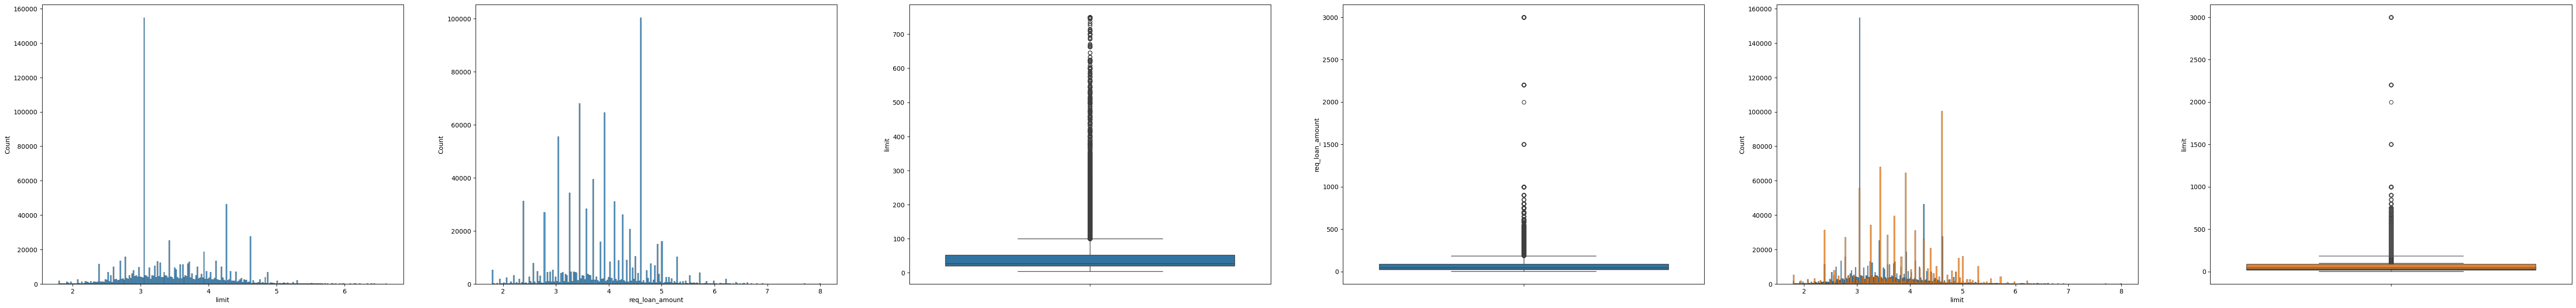

In [70]:
plt.figure(figsize=(72,8))
plt.subplot(1,6,1)
sns.histplot(np.log1p(train_df['limit']))
plt.subplot(1,6,2)
sns.histplot(np.log1p(train_df['req_loan_amount']))
plt.subplot(1,6,3)
sns.boxplot(train_df['limit'])
plt.subplot(1,6,4)
sns.boxplot(train_df['req_loan_amount'])
plt.subplot(1,6,5)
sns.histplot(np.log1p(train_df['limit']))
sns.histplot(np.log1p(train_df['req_loan_amount']))
plt.subplot(1,6,6)
sns.boxplot(train_df['limit'])
sns.boxplot(train_df['req_loan_amount'])
plt.show()

# feat EDA

In [88]:
info = pd.DataFrame({
    'name_cols': feat.columns,
    'isna': feat.isna().sum(),
    'dtypes': feat.dtypes,
    'unique': feat.nunique(),
})
display(info)

,name_cols,isna,dtypes,unique
app_id,app_id,0,str,76435
date_part,date_part,0,str,89
invest_rur_amt,invest_rur_amt,63139,float64,5318
clientsegment,clientsegment,2919,str,4
active_claim_flag,active_claim_flag,2232,float64,1
...,...,...,...,...
hdb_bki_total_active_products,hdb_bki_total_active_products,3170,float64,111
hdb_bki_total_cc_max_limit,hdb_bki_total_cc_max_limit,4486,float32,5685
hdb_loans_5_30_days_del,hdb_loans_5_30_days_del,3173,float64,283
hdb_bki_active_oth_max_overdue,hdb_bki_active_oth_max_overdue,64781,float32,3508


In [97]:
info['dtypes'].value_counts()

dtypes
float64    200
float32     39
str         34
object       7
Name: count, dtype: int64

In [126]:
display(info[info['dtypes'] == 'str'])
print(len(feat['app_id']))

,name_cols,isna,dtypes,unique
app_id,app_id,0,str,76435
date_part,date_part,0,str,89
clientsegment,clientsegment,2919,str,4
country,country,1688,str,1
clienttype,clienttype,1688,str,1
clientgroup,clientgroup,1688,str,1
clientoutflowstatus,clientoutflowstatus,2232,str,9
srvpackage_fst,srvpackage_fst,1688,str,31
clientsegment_prd,clientsegment_prd,3072,str,6
lp_client_group_name,lp_client_group_name,67075,str,3


76583


In [161]:
feat['realty_flag'].unique().tolist()

[nan, 'N']

In [ ]:
[info['name_cols'] == '_data']

In [ ]:
len(feat[feat['lp_client_group_name'] == 'ЮЛ']['clienttype'])

2663